In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ANNOTATIONS_URL = "https://omnipathdb.org/annotations"

COLLECTION_MAP = {
    "hallmark": "hallmark",
    "kegg": "kegg",
    "reactome": "reactome",
    "go_bp": "go_biological_process",
    "go_mf": "go_molecular_function",
    "go_cc": "go_cellular_component",
}

In [3]:
def fetch_msigdb():
    import urllib.request
    import urllib.parse
    url = (
        ANNOTATIONS_URL
        + "?"
        + urllib.parse.urlencode({"databases": "MSigDB", "license": "academic"})
    )

    df = pd.read_csv(urllib.request.urlopen(url), sep="\t", low_memory=False)
    return df

In [4]:
def parse_msigdb(df):
    df = df[df["label"].isin(["collection", "geneset", "genesymbol"])]

    pivot = df.pivot_table(
        index=["record_id", "genesymbol"],
        columns="label",
        values="value",
        aggfunc="first",
    ).reset_index()

    pivot = pivot.dropna(subset=["collection", "geneset", "genesymbol"])

    return pivot[["collection", "geneset", "genesymbol"]]

In [5]:
def compute_sizes(pivot):
    sizes = (
        pivot.groupby(["collection", "geneset"])["genesymbol"]
        .nunique()
        .reset_index(name="gene_set_size")
    )

    return sizes

In [6]:
raw = fetch_msigdb()
parsed = parse_msigdb(raw)
summary = compute_sizes(parsed)

In [7]:
# remove irrelevant collections
summary = summary[
    ~summary["collection"].isin(
        [
            "chemical_and_genetic_perturbations",
            "human_phenotype_ontology",
            "cancer_gene_neighborhoods",
            "cancer_modules",
            "cancer_cell_atlas",
            "vaccine_response",
            "tf_targets_gtrf",
            "tf_targets_legacy",
            "positional",
            "pid_pathways",
            "cell_type_signatures",
        ]
    )
]

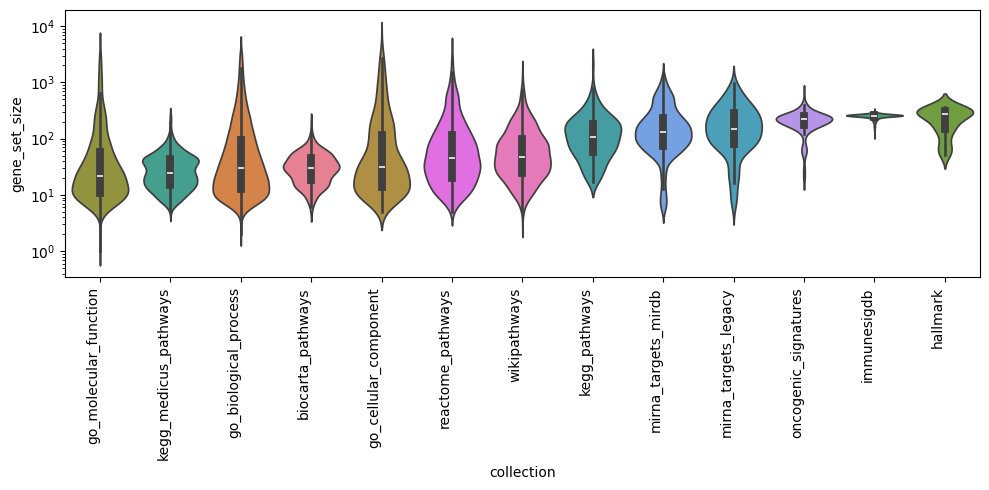

In [8]:
# order by median
order = summary.groupby("collection")["gene_set_size"].median().sort_values().index

plt.figure(figsize=(10, 5))

ax = sns.violinplot(
    data=summary,
    x="collection",
    y="gene_set_size",
    inner="box",
    order=order,
    log_scale=True,
    hue="collection",
)

# overlay median + SEM as points + error bars
stats = (
    summary.groupby("collection")["gene_set_size"]
    .agg(median="median", sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    .reindex(order)
)

x = np.arange(len(order))

plt.xticks(rotation=90, ha="right")

plt.tight_layout()
plt.savefig("figures/gene_set_size_boxplot_median_sem.pdf", dpi=300)
plt.show()